# Directory for Figures Cool-Hot

In [1]:
import os

# Définir le chemin de base et le répertoire à créer
base_dir = "G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2"
saving_dir = os.path.join(base_dir, "Plot_for_figure_thq")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' la été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2\Plot_for_figure_thq' existe déjà.


# 1. Plot Thq rec exemple (2023.11.09 - T1)

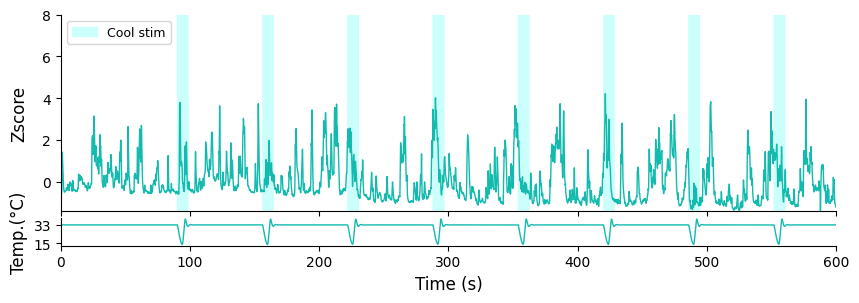

In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter  # Importer la fonction savgol_filter
import pandas as pd

# 1. Chargement des données pour les deux DataFrames
df_cool = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_thermic_Zscore_classic.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_cool = '2023.11.09'  # Remplacez par l'animal souhaité
rec_cool = 'Thermic_1'  # Remplacez par le rec souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_cool_filtered = df_cool[(df_cool['animal'] == animal_cool) & (df_cool['rec'] == rec_cool)].copy()

# Conversion du temps en secondes pour les deux DataFrames
df_cool_filtered.loc[:, 'time_sec'] = df_cool_filtered['time'] / 1000

# Appliquer un filtre de lissage (moyenne mobile) sur le Z-score et la température
window_length = 5  # Taille de la fenêtre (doit être impair)
polyorder = 3  # Ordre du polynôme

df_cool_filtered['Z-score_smoothed'] = savgol_filter(df_cool_filtered['Z-score'], window_length=window_length, polyorder=polyorder)


# 4. Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Premier Subplot : Z-score pour les deux conditions
sns.lineplot(x='time_sec', y='Z-score_smoothed', data=df_cool_filtered, ax=ax1, color='#13bbaf', linewidth=1) #label='Cool stim')

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore', labelpad=10)
ax1.set_ylim(-1.4, 8)
ax1.set_xlim(0, 600)
# ax1.set_title('Zscore variation for cool and hot stim')

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#cafffb'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_cool_filtered[df_cool_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_thermic = row['time'] / 1000
    end_time_thermic = (row['time'] + 3900) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_thermic, end_time_thermic, color=thermic_color, zorder=0, label='Cool stim') #if i == 0 else "")

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Deuxième Subplot : Variation de la Température pour les deux DataFrames
sns.lineplot(x='time_sec', y='temperature', data=df_cool_filtered, ax=ax2, color='#13bbaf', linewidth=1)

# Ajuster les labels
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout



# Afficher le graphique
plt.show()


# 2. Plot PSTC

La valeur maximale de la courbe moyenne est 0.6592 et elle se produit à 2.7000 secondes.


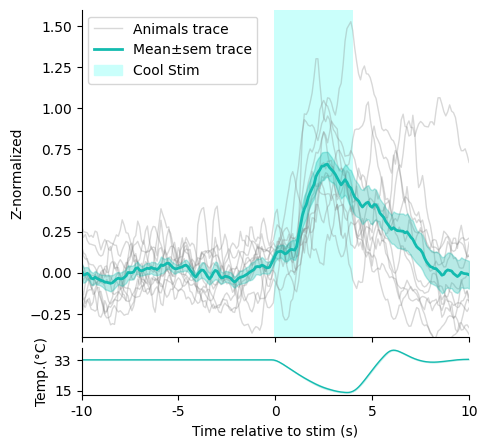

In [1]:

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_Thq_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_thermic_Zscore_classic_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Z-score_norm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Zscore_norm', 
        color=gray_color, linewidth=1, ax=ax1, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax1.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()

# Trouver la valeur maximale de la courbe moyenne et le temps correspondant
max_value = mean_zscore['Mean_Zscore_norm'].max()
max_time = mean_zscore.loc[mean_zscore['Mean_Zscore_norm'].idxmax(), 'time_sec']

# Afficher la valeur maximale et son temps associé
print(f"La valeur maximale de la courbe moyenne est {max_value:.4f} et elle se produit à {max_time:.4f} secondes.")

# Tracer la courbe moyenne
ax1.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', linewidth=2, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Zscore_norm
ax1.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Zscore_norm'] - SEM_zscore['Mean_Zscore_norm'], 
    mean_zscore['Mean_Zscore_norm'] + SEM_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Zscore_norm'].min()
y_max = df_combined['Mean_Zscore_norm'].max()

# Ajuster les limites de l'axe y
ax1.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax1.get_ylim()[0] - y_min
y_max_diff = ax1.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax1.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Cool Stim', zorder=1
)

# Deuxième subplot : Variation de la Température

sns.lineplot(
    data=df_combined, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend()
# ax1.set_title('Peristimulus curve for cool vs hot stimulation')

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.39, 1.6)
ax1.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout

# Afficher le graphique
plt.show()



# 3. Combo PSTC and Heatmap

La valeur maximale de Z-score_norm entre 0 et 3.9 secondes est : 6.750609221553712


C:\Users\zayan\AppData\Local\Temp\ipykernel_74164\631670090.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_mean_combined = df_cool.groupby('Stim').apply(lambda x: pd.Series({
C:\Users\zayan\AppData\Local\Temp\ipykernel_74164\631670090.py:291: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


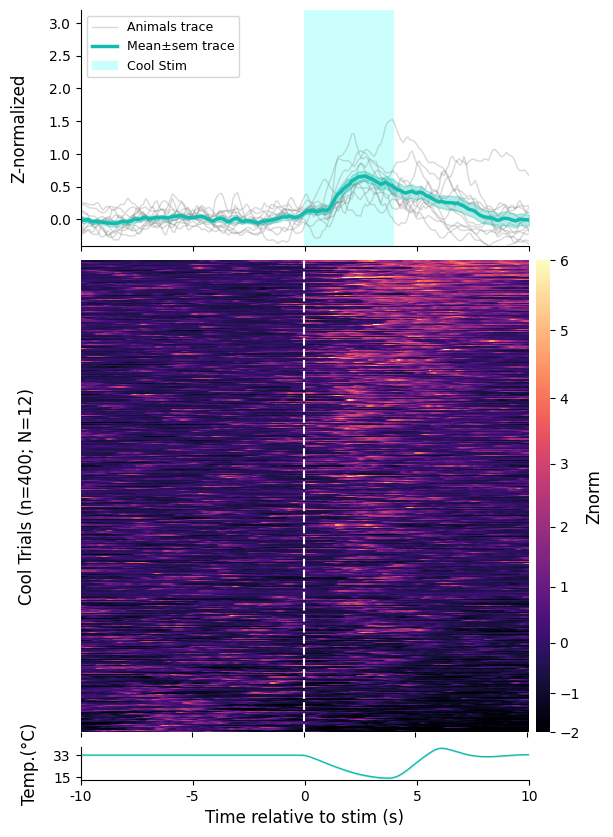

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_Thq_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_thermic_Zscore_classic_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes



########################################################## HEATMAP #####################################################################

# Lire les fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_thermic_Zscore_classic_stim.xlsx'
df_cool = pd.read_excel(file_path_cool)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_cool['Z-score_norm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)



# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_cool, 'Cool')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_cool['Stim_Time_sec'] = df_cool['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_cool[(df_cool['Stim_Time_sec'] >= 0) & (df_cool['Stim_Time_sec'] <= 3.9)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Z-score_norm'].max()

print("La valeur maximale de Z-score_norm entre 0 et 3.9 secondes est :", max_znorm_value)


# Calculer la moyenne pondérée des Z-scores pour chaque trial dans le DataFrame combiné
weighted_mean_combined = df_cool.groupby('Stim').apply(lambda x: pd.Series({
    'weighted_mean': (x['Z-score_norm'] * x['temperature']).sum() / x['temperature'].sum()
}))

# Créer la heatmap pour le DataFrame combiné
df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')

# Réintégrer la colonne 'Condition' avant le tri
df_heatmap_combined = df_heatmap_combined.join(df_cool[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Joindre la moyenne pondérée pour trier les données
df_heatmap_combined = df_heatmap_combined.join(weighted_mean_combined).sort_values(by=['Condition', 'weighted_mean'], ascending=[True, False])

# Trouver l'index où les conditions 'Hot' commencent
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])

# Préparer les données pour la variation de température moyenne
temp_mean_cool = df_cool.groupby('Stim_Time_sec')['temperature'].mean()


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)
# gs = gridspec.GridSpec(nrows=3, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Z-score_norm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Zscore_norm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', linewidth=2.5, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Zscore_norm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Zscore_norm'] - SEM_zscore['Mean_Zscore_norm'], 
    mean_zscore['Mean_Zscore_norm'] + SEM_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Zscore_norm'].min()
y_max = df_combined['Mean_Zscore_norm'].max()

# Ajuster les limites de l'axe y
ax0.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax0.get_ylim()[0] - y_min
y_max_diff = ax0.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 5 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Cool Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad=15)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.4, 3.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé à partir de la palette 'magma'
# en limitant le segment de couleurs à une plage plus petite pour plus de contraste
base_palette = sns.color_palette("magma", as_cmap=True)

norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)  # Plus gamma est petit, plus les valeurs extrêmes sont saturées rapidement

# Créer la heatmap
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition', 'weighted_mean']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1, vmin=-2, vmax=6)


# Ajouter une ligne verticale en pointillée centrée sur 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)

# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])

# Supprimer les xticklabels et le xlabel
ax1.set_xticklabels([])
ax1.set_xlabel('')

# Modifier les yticklabels pour avoir un compte régulier de 1 au nombre total de trials
yticks_labels = ['' for _ in range(len(df_heatmap_combined.index))]  # Étiquettes vides

# Calculer les positions des ticks
# ticks = list(range(0, len(yticks_labels), 1))
# ax1.set_yticks(ticks)
ax1.set_yticks([])
ax1.set_yticklabels([])  # Supprimer les étiquettes de l'axe y
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

# Supprimer l'étiquette "Trial Index"
ax1.set_ylabel('')

# Ajouter les étiquettes verticales pour les trials Cool et Hot avec le nombre de trials uniques
ax1.text(-20, num_cool_trials / 2, f'Cool Trials (n={num_cool_trials}; N=12)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')


################# Variation de température  #################

ax2 = plt.subplot(gs[2, 0])

sns.lineplot(
    data=df_combined, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Enlever les bordures du haut et de droite
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

plt.show()


# 4. Ploting AUC

### 4.1. N = animals


Test de Shapiro-Wilk pour Cool:
Période: TB, Statistique: 0.9591, p-value: 0.7707
Les données pour TB suivent une distribution normale (p >= 0.05).
Période: TS, Statistique: 0.9373, p-value: 0.4644
Les données pour TS suivent une distribution normale (p >= 0.05).
Période: PTS, Statistique: 0.9320, p-value: 0.4018
Les données pour PTS suivent une distribution normale (p >= 0.05).

Test de Friedman pour AUC_Znorm_persec (cool):
Chi-square: 12.166666666666657, p-value: 0.0022805620953921715
Comparaisons post-hoc (AUC_Znorm_persec, cool) :
          PTS        TB        TS
PTS  1.000000  0.243627  0.081585
TB   0.243627  1.000000  0.000232
TS   0.081585  0.000232  1.000000
Condition: Cool, Period: TB, Size: 12, Mean: 0.1799, SEM: 0.0327
Condition: Cool, Period: TS, Size: 12, Mean: 3.9815, SEM: 0.5383
Condition: Cool, Period: PTS, Size: 12, Mean: 2.0663, SEM: 0.7860


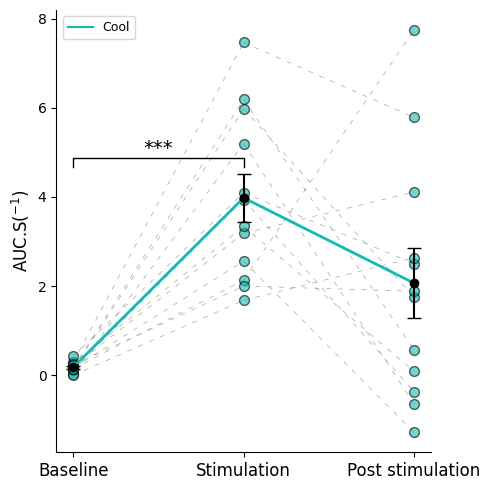

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os
import matplotlib.lines as mlines

# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'

# Définir les périodes
periods = ['TB', 'TS', 'PTS']


# Fonction pour effectuer le test de Shapiro-Wilk
def shapiro_test(df, condition_name, variable_name):
    print(f"\nTest de Shapiro-Wilk pour {condition_name}:")
    for period in periods:
        data = df[(df['Condition'] == condition_name) & (df['Period'] == period)][variable_name]
        stat, p_value = shapiro(data)
        print(f"Période: {period}, Statistique: {stat:.4f}, p-value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"Les données pour {period} ne suivent pas une distribution normale (p < 0.05).")
        else:
            print(f"Les données pour {period} suivent une distribution normale (p >= 0.05).")


# Appliquer le test de Shapiro-Wilk pour la condition Cool
shapiro_test(df_auc_cool, 'Cool', 'AUC_Znorm_persec')


# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period'] == 'PTS'][variable_name],
        df[df['Period'] == 'TB'][variable_name],
        df[df['Period'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_cool, posthoc_results_auc_cool = friedman_posthoc(df_auc_cool, 'AUC_Znorm_persec', 'cool')

# Filtrer les données par période pour chaque variable
df_periods = {
    'Cool': {period: df_auc_cool[(df_auc_cool['Period'] == period) & (df_auc_cool['Condition'] == 'Cool')] for period in periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {'AUC_Znorm_persec_cool': '#13bbaf'
}
border_colors = {key: 'black' for key in colors}


# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period]] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems


# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_cool = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_cool'], label='Cool')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_cool], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]], positions[periods[i + 1]]
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_auc_cool, condition_name, variable_name,color):
    # Filtrer par condition et par animal
    for animal in df_auc_cool[df_auc_cool['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_auc_cool[(df_auc_cool['Condition'] == condition_name) & (df_auc_cool['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] 
            x2 = positions[periods[i + 1]]
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_auc_cool, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'])


def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.2, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition Cool
y_offset = 4.5  # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre chaque barre de significativité

if posthoc_results_auc_cool is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_cool.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = means_cool[period_1] + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Fonction pour calculer les statistiques (taille, moyenne, SEM)
def calculate_stats(df, condition_name, variable_name):
    stats = {}
    for period in periods:
        data = df[(df['Condition'] == condition_name) & (df['Period'] == period)][variable_name]
        size = len(data)
        mean = data.mean()
        sem = data.sem()
        stats[period] = {'Size': size, 'Mean': mean, 'SEM': sem}
        print(f"Condition: {condition_name}, Period: {period}, Size: {size}, Mean: {mean:.4f}, SEM: {sem:.4f}")
    return stats

# Calcul des stats pour la condition "Cool"
stats_cool = calculate_stats(df_auc_cool, 'Cool', 'AUC_Znorm_persec')


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
# plt.grid(axis='y')


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()


plt.show()


### 4.2. N = trials

  Condition Period_type  Sample_Size      Mean       SEM
0      Cool         PTS          400  1.836715  0.409797
1      Cool          TB          400  0.170416  0.025952
2      Cool          TS          400  4.232704  0.420103

Résultats du test de Shapiro-Wilk :
  Period  Shapiro Statistic       p-value
0     TB           0.945863  6.448061e-11
1     TS           0.989906  7.509358e-03
2    PTS           0.981984  6.938384e-05

Interprétation :
Les données pour la période TB NE suivent PAS une distribution normale (p = 0.000).
Les données pour la période TS NE suivent PAS une distribution normale (p = 0.008).
Les données pour la période PTS NE suivent PAS une distribution normale (p = 0.000).

Test de Friedman pour AUC_Znorm_persec (cool):
Chi-square: 61.73999999999978, p-value: 3.920390640071306e-14
Comparaisons post-hoc (AUC_Znorm_persec, cool) :
          PTS            TB            TS
PTS  1.000000  5.509264e-06  3.512456e-04
TB   0.000006  1.000000e+00  1.960158e-17
TS   0.0003

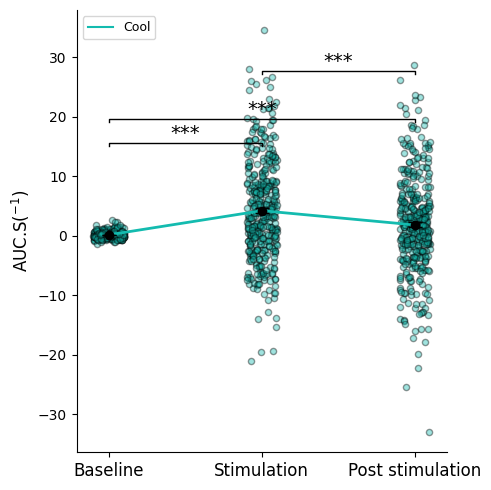

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')


# Définir les périodes
Periods = ['TB', 'TS', 'PTS']

# Calculer les statistiques pour chaque condition et chaque période
stats = df_auc_cool.groupby(['Condition', 'Period_type']).agg(
    Sample_Size=('AUC_Znorm_persec', 'count'),
    Mean=('AUC_Znorm_persec', 'mean'),
    SEM=('AUC_Znorm_persec', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()


# Afficher les résultats
print(stats)


# Fonction pour effectuer le test de Shapiro-Wilk
def perform_shapiro_test(df, variable_name, group_col):
    results = []
    for period in Periods:
        subset = df[df[group_col] == period][variable_name]
        if len(subset) < 3:  # Le test nécessite au moins 3 valeurs
            print(f"Le test de Shapiro ne peut pas être effectué pour {period} (échantillon trop petit).")
            continue
        stat, p_value = shapiro(subset)
        results.append({
            'Period': period,
            'Shapiro Statistic': stat,
            'p-value': p_value
        })
    return pd.DataFrame(results)

# Effectuer le test de Shapiro-Wilk pour chaque période
shapiro_results = perform_shapiro_test(df_auc_cool, 'AUC_Znorm_persec', 'Period_type')

# Afficher les résultats
print("\nRésultats du test de Shapiro-Wilk :")
print(shapiro_results)

# Interprétation des résultats
print("\nInterprétation :")
for _, row in shapiro_results.iterrows():
    if row['p-value'] < 0.05:
        print(f"Les données pour la période {row['Period']} NE suivent PAS une distribution normale (p = {row['p-value']:.3f}).")
    else:
        print(f"Les données pour la période {row['Period']} suivent une distribution normale (p = {row['p-value']:.3f}).")


# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period_type'] == 'PTS'][variable_name],
        df[df['Period_type'] == 'TB'][variable_name],
        df[df['Period_type'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period_type', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_cool, posthoc_results_auc_cool = friedman_posthoc(df_auc_cool, 'AUC_Znorm_persec', 'cool')

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_auc_cool[(df_auc_cool['Period_type'] == Period) & (df_auc_cool['Condition'] == 'Cool')] for Period in Periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {
    'AUC_Znorm_persec_cool': '#13bbaf'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period]] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_Periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_cool = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_cool'], label='Cool')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_cool], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]], positions[Periods[i + 1]]
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_trials_grouped(df_auc_cool, condition_name, variable_name, color):
    # Filtrer par condition
    condition_data = df_auc_cool[df_auc_cool['Condition'] == condition_name]

    # Grouper les données par Animal, Rec et Trial
    grouped_data = condition_data.groupby(['Animal', 'Rec', 'Trial'])

    # Parcourir chaque groupe
    for (animal, rec, trial), group in grouped_data:
        # Relier les points pour chaque période pour cet animal et cet enregistrement
        for i, Period in enumerate(Periods[:-1]):
            # Vérifier que les données des deux périodes existent
            if Period in group['Period'].values and Periods[i + 1] in group['Period'].values:
                x1 = positions[Period]
                x2 = positions[Periods[i + 1]]
                y1 = group[group['Period'] == Period][variable_name].values[0]
                y2 = group[group['Period'] == Periods[i + 1]][variable_name].values[0]

                # Tracer une ligne entre les points
                plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10),
                         linewidth=0.5, alpha=0.7, zorder=0)

# Appeler la fonction pour tracer les connexions
plot_connections_per_trials_grouped(df_auc_cool, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'])


# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.35

def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition Cool
y_offset = 15  # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc_results_auc_cool is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_cool.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = means_cool[period_1] + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()



plt.show()


# 5. Response rate by condition

### 5.1. with N = animals

taux moyen de réponse Thermic =54.01041666666666±3.3617324210265176

Taille des échantillons : 12


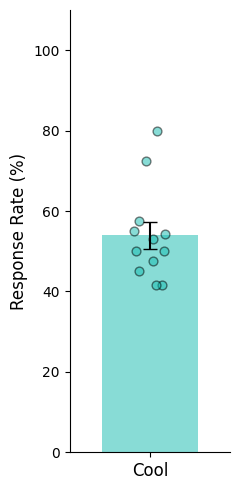

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Chemin du fichier Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Lecture du fichier Excel
df_cool = pd.read_excel(file_path_cool)

# Calcul du taux de réponse moyen par animal
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # Conversion en pourcentage

# Calcul de la moyenne et de l'écart-type de réponse par animal
mean_response_per_animal = response_data_cool.groupby('animal')['response_rate'].mean()

# Calcul des statistiques globales
mean_response = mean_response_per_animal.mean()
sem_response = mean_response_per_animal.sem()

print (f"taux moyen de réponse Thermic ={mean_response}±{sem_response}")

plt.figure(figsize=(2.5, 5))

# Tracé de la barre
plt.bar(
    [0.5],  # Position centrale pour la barre
    mean_response,
    width=0.6,  # Changez cette valeur pour ajuster la largeur
    yerr=sem_response,
    color='#13bbaf',
    alpha=0.5,
    capsize=5,
    label='Cool Stim'
)

# Ajout des points individuels avec jitter
np.random.seed(42)  # Assurer la reproductibilité
jitter = np.random.uniform(-0.1, 0.1, size=len(mean_response_per_animal))  # Générer un jitter aléatoire
x_positions = [0.5 + j for j in jitter]  # Ajouter le jitter autour de x=0.5

plt.scatter(
    x_positions,  # Utiliser les positions avec jitter
    mean_response_per_animal,
    color='#13bbaf',
    alpha=0.5,
    edgecolor='black',
    s=40
)

# Vérification des tailles d'échantillons
sample_size_cool = len(mean_response_per_animal)  # Taille de l'échantillon pour Cool

print(f"\nTaille des échantillons : {sample_size_cool}")

# Mise en forme du graphique
plt.xticks([0.5], ['Cool'])  # Placez l'étiquette au centre
plt.xlim(0, 1)  # Ajustez les limites pour encadrer la barre
plt.ylabel("Response Rate (%)")
plt.ylim(0, 110)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()



plt.show()


# 6. Above threshold rate

### 6.1. with n = animals

Moyennes (mean) par période:
period_type
PTS     8.899361
TB      2.887500
TS     13.029542
Name: Norm_response_rate, dtype: float64

Erreur standard (SEM) par période:
period_type
PTS    0.769980
TB     0.176891
TS     0.940273
Name: Norm_response_rate, dtype: float64

Test de normalité pour la période TB : n = 12
Statistique = 0.9265, p-value = 0.3446

Test de normalité pour la période TS : n = 12
Statistique = 0.9037, p-value = 0.1771

Test de normalité pour la période PTS : n = 12
Statistique = 0.8478, p-value = 0.0345

Résultats du Test de Friedman :
n (TB) = 12
n (TS) = 12
n (PTS) = 12
Statistique = 18.5000, p-value = 0.0001

Test de Dunn post-hoc pour comparer les périodes :
           TS        TB       PTS
TS   1.000000  0.000004  0.003642
TB   0.000004  1.000000  0.323445
PTS  0.003642  0.323445  1.000000


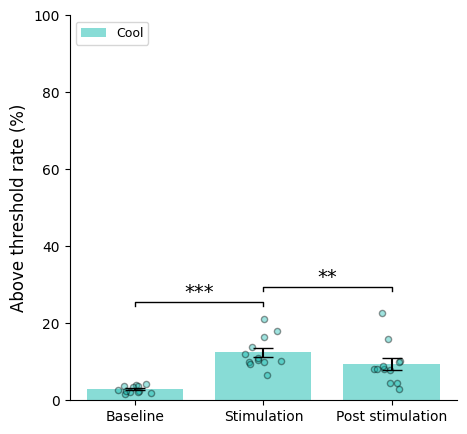

In [8]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = df_cool[df_cool['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()

# Moyenne des animaux pour chaque période (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate']
})

# Calcul des moyennes et SEM par période
mean_cool = df_cool.groupby('period_type')['Norm_response_rate'].mean()
sem_cool = df_cool.groupby('period_type')['Norm_response_rate'].sem()

# Affichage des résultats
print("Moyennes (mean) par période:")
print(mean_cool)

print("\nErreur standard (SEM) par période:")
print(sem_cool)

# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = mean_cool_animal[mean_cool_animal['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')

# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [mean_cool_animal[mean_cool_animal['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar(mean_response_data['period'],
        height=mean_response_data['mean_response_cool'],
        width=bar_width, 
        yerr=mean_response_data['sem_response_cool'],
        label='Cool', 
        color='#13bbaf', 
        alpha=0.5, 
        capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)

# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=1, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.15, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 12  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    significance_y_position = max(mean_response_data['mean_response_cool'][idx], mean_response_data['mean_response_cool'][jdx]) + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Afficher le graphique
plt.show()


### 6.2. with n = Trials

Moyenne des taux de réponse :
  period_type  Norm_response_rate
0          TB            2.887500
1          TS           13.029542
2         PTS            8.899361

Erreur standard de la moyenne (SEM) des taux de réponse :
  period_type  Norm_response_rate
0          TB            0.176891
1          TS            0.940273
2         PTS            0.769980

Test de normalité pour la période TB : n = 400
Statistique = 0.8082, p-value = 0.0000

Test de normalité pour la période TS : n = 400
Statistique = 0.7351, p-value = 0.0000

Test de normalité pour la période PTS : n = 400
Statistique = 0.6424, p-value = 0.0000

Résultats du Test de Friedman :
n (TB) = 400
n (TS) = 400
n (PTS) = 400
Statistique = 25.7867, p-value = 0.0000

Test de Dunn post-hoc pour comparer les périodes :
               TS            TB       PTS
TS   1.000000e+00  2.356999e-07  0.127061
TB   2.356999e-07  1.000000e+00  0.002510
PTS  1.270614e-01  2.510071e-03  1.000000


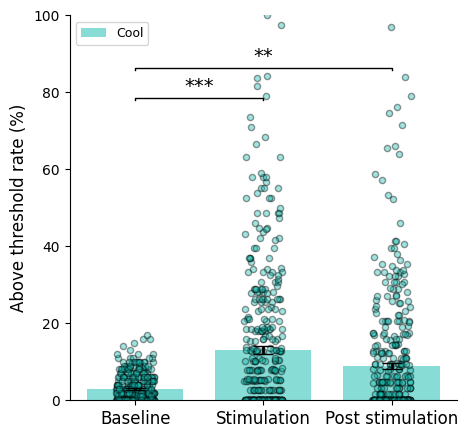

In [14]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_trial = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_trial.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = df_cool_trial.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_trial = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate']
})

# Affichage des résultats moyens et SEM pour chaque condition
print("Moyenne des taux de réponse :")
print(mean_cool)

print("\nErreur standard de la moyenne (SEM) des taux de réponse :")
print(sem_cool)

# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = df_cool_trial[df_cool_trial['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [df_cool_trial[df_cool_trial['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période
bar_width = 0.75
x = range(len(mean_response_trial['period']))

# Barres pour la condition Cool sans erreur (seulement les barres)
plt.bar(mean_response_trial['period'],
        height=mean_response_trial['mean_response_cool'],
        width=bar_width, 
        label='Cool', 
        color='#13bbaf', 
        alpha=0.5, 
        zorder=0
        )

# Ajouter les barres d'erreur pour chaque période (en utilisant plt.errorbar)
plt.errorbar(mean_response_trial['period'],
             mean_response_trial['mean_response_cool'],
             yerr=mean_response_trial['sem_response_cool'],
             fmt='none',  # Pas de marqueur supplémentaire pour les erreurs
             ecolor='black',  # Couleur des erreurs
             capsize=7,       # Taille des caps pour les erreurs
             elinewidth=2,    # Épaisseur des lignes d'erreur
             zorder=3         # Les erreurs seront au-dessus des barres
             )

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_trial[df_cool_trial['period_type'] == period]['Norm_response_rate']
    
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4, zorder=0)


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset =  65
spacing_between_bars = 12  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    significance_y_position = max(mean_response_trial['mean_response_cool'][idx], mean_response_trial['mean_response_cool'][jdx]) + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_trial['period'])
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})


# Afficher le graphique
plt.show()


# 7. Magnitude of the response

### 7.1. N = animals 

Moyenne et SEM de chaque période :
Période TB: Moyenne = 0.0691, SEM = 0.0064
Période TS: Moyenne = 0.3283, SEM = 0.0337
Période PTS: Moyenne = 0.2381, SEM = 0.0398

Test de normalité pour la période TB : n = 12
Statistique = 0.9030, p-value = 0.1735

Test de normalité pour la période TS : n = 12
Statistique = 0.9177, p-value = 0.2673

Test de normalité pour la période PTS : n = 12
Statistique = 0.8687, p-value = 0.0629

Résultats du Test de Friedman :
n (TB) = 12
n (TS) = 12
n (PTS) = 12
Statistique = 18.5000, p-value = 0.0001

Test de Dunn pour comparer les périodes Thq :
           TS        TB       PTS
TS   1.000000  0.000003  0.003897
TB   0.000003  1.000000  0.298772
PTS  0.003897  0.298772  1.000000


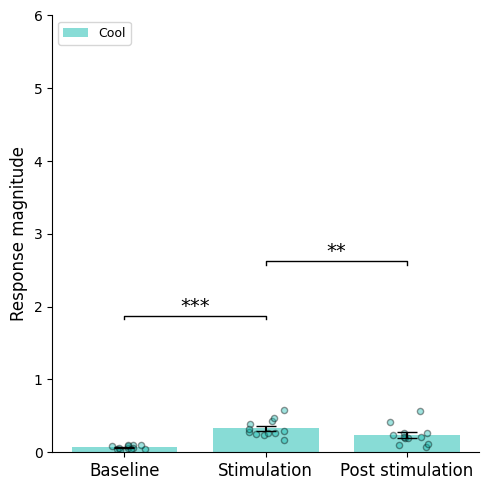

In [13]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool], ['Cool']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()


# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude']
})

# Affichage des moyennes et SEM pour chaque période
print("Moyenne et SEM de chaque période :")

# Périodes à afficher
periods = ['TB', 'TS', 'PTS']

# Afficher les résultats pour chaque période
for period in periods:
    mean_value = mean_cool.loc[mean_cool['period_type'] == period, 'response_magnitude'].values[0]
    sem_value = sem_cool.loc[sem_cool['period_type'] == period, 'response_magnitude'].values[0]
    print(f"Période {period}: Moyenne = {mean_value:.4f}, SEM = {sem_value:.4f}")


# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = mean_cool_animal
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']

    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition (Cool et Hot)
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = mean_cool_animal

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_results_magnitude = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = mean_cool_animal

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_results_magnitude = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results_magnitude.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results_magnitude.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results_magnitude)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['response_magnitude']

    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)


# Ajouter les barres de significativité du test de Dunn
# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.05, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 1.5    # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 0.75  # Espacement entre chaque barre de significativité

if posthoc_results_magnitude is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_magnitude.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    significance_y_position = max(mean_response_data['mean_response_cool'][idx], mean_response_data['mean_response_cool'][jdx]) + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()



plt.show()


### 7.2. N = Trials

             period  mean_response_cool  sem_response_cool
0          Baseline            0.068790           0.004385
1       Stimulation            0.344108           0.026597
2  Post stimulation            0.227462           0.020504

Test de normalité pour la période TB : n = 400
Statistique = 0.7931, p-value = 0.0000

Test de normalité pour la période TS : n = 400
Statistique = 0.6993, p-value = 0.0000

Test de normalité pour la période PTS : n = 400
Statistique = 0.6203, p-value = 0.0000

Résultats du Test de Friedman :
n (TB) = 400
n (TS) = 400
n (PTS) = 400
Statistique = 24.9706, p-value = 0.0000

Test de Dunn pour comparer les périodes Thq :
               TS            TB       PTS
TS   1.000000e+00  7.765930e-07  0.183251
TB   7.765930e-07  1.000000e+00  0.003133
PTS  1.832511e-01  3.133224e-03  1.000000


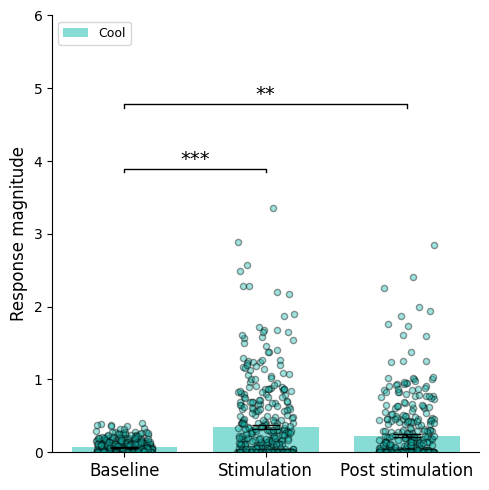

In [16]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare


# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')

# Compter le nombre d'observations par période et par animal
sample_sizes = df_cool.groupby(['animal', 'period_type']).size().reset_index(name='count')

# Vérifier si toutes les périodes ont exactement 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = sample_sizes[sample_sizes['period_type'] == period]

# Extraire le type de période (TS, TB, PTS)
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_filtered = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]


# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude']
})

# Afficher les moyennes et SEM pour chaque période
print(mean_response_data)

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = df_cool_filtered
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")
    
    stat, p_value = shapiro(period_data)
    normality_results[period]= {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition (Cool et Hot)
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = df_cool_filtered

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_magnitude_trials = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = df_cool_filtered

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_magnitude_trials = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_magnitude_trials.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_magnitude_trials.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_magnitude_trials)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', linewidth=2,alpha=0.5, capsize=10)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['response_magnitude']
     # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.2  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)



# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.05, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter les barres de significativité du test de Dunn
if isinstance(posthoc_magnitude_trials, pd.DataFrame):  # Vérifiez si c'est un DataFrame
    y_offset = 3.5  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
    spacing_between_bars = 1  # Espacement entre chaque barre de significativité

    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_magnitude_trials.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    significance_y_position = max(mean_response_data['mean_response_cool'][idx], mean_response_data['mean_response_cool'][jdx]) + y_offset
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut
else:
    print("Les résultats du test de Dunn ne sont pas disponibles ou ne sont pas significatifs.")



# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim (0,6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


# 8. Trial heatmap

C:\Users\zayan\AppData\Local\Temp\ipykernel_34072\3565650232.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_mean_combined = df_cool.groupby('Stim').apply(lambda x: pd.Series({


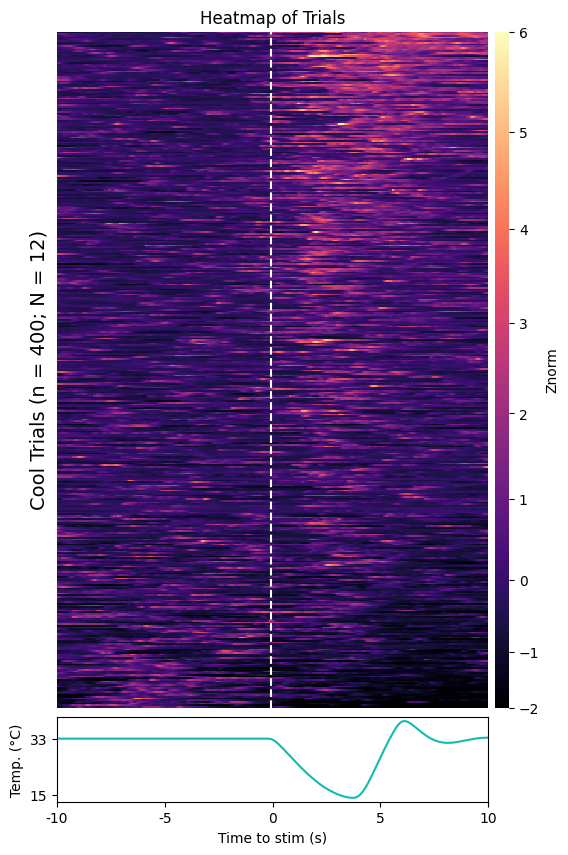

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os

# Lire les fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_thermic_Zscore_classic_stim.xlsx'
df_cool = pd.read_excel(file_path_cool)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_cool, 'Cool')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_cool['Stim_Time_sec'] = df_cool['Stim_Time'] / 1000


# Calculer la moyenne pondérée des Z-scores pour chaque trial dans le DataFrame combiné
weighted_mean_combined = df_cool.groupby('Stim').apply(lambda x: pd.Series({
    'weighted_mean': (x['Z-score_norm'] * x['temperature']).sum() / x['temperature'].sum()
}))

# Créer la heatmap pour le DataFrame combiné
df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')

# Réintégrer la colonne 'Condition' avant le tri
df_heatmap_combined = df_heatmap_combined.join(df_cool[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Joindre la moyenne pondérée pour trier les données
df_heatmap_combined = df_heatmap_combined.join(weighted_mean_combined).sort_values(by=['Condition', 'weighted_mean'], ascending=[True, False])

# Trouver l'index où les conditions 'Hot' commencent
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])
num_hot_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Hot'])

# Préparer les données pour la variation de température moyenne
temp_mean_cool = df_cool.groupby('Stim_Time_sec')['temperature'].mean()

# Créer la figure et les sous-graphes avec un Gridspec pour plus de contrôle
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=2, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[8, 1], hspace=0.025)  # Ajuster la grille

# Heatmap pour les données combinées
ax1 = plt.subplot(gs[0, 0])
cbar_ax = plt.subplot(gs[0, 1])

# Créer un gradient personnalisé à partir de la palette 'magma'
# en limitant le segment de couleurs à une plage plus petite pour plus de contraste
base_palette = sns.color_palette("magma", as_cmap=True)

norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)  # Plus gamma est petit, plus les valeurs extrêmes sont saturées rapidement

heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition', 'weighted_mean']),
                               cmap = base_palette, norm = norm, vmin=-2, vmax=6, cbar_ax=cbar_ax, ax=ax1) # Valeur de Znorm limité a -2 pour avoir contraste

# Ajouter une ligne verticale en pointillée centrée sur 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])

# Placer les labels et ajuster les marges
ax1.set_title('Heatmap of Trials')

# Supprimer les xticklabels et le xlabel
ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.set_xticks([])

# Modifier les yticklabels pour avoir un compte régulier de 1 au nombre total de trials
yticks_labels = ['' for _ in range(len(df_heatmap_combined.index))]  # Étiquettes vides
ax1.set_yticks([])
ax1.set_yticklabels([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')# Supprimer l'étiquette "Trial Index"

# Ajouter les étiquettes verticales pour les trials Cool et Hot avec le nombre de trials uniques
ax1.text(-4, num_cool_trials / 2, f'Cool Trials (n = {num_cool_trials}; N = 12)', fontsize=14, color='black', va='center', ha='right', rotation='vertical')

# Plot de la variation de température moyenne pour cool et hot
ax2 = plt.subplot(gs[1, 0])
ax2.plot(temp_mean_cool.index, temp_mean_cool.values, label='Cool', color='#13bbaf')
ax2.set_xlabel('Time to stim (s)')
ax2.set_ylabel('Temp. (°C)')
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)  # Limites de l'axe x
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])



plt.rcParams.update({
    'axes.titlesize': 14,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})



# Affichage du graphique
plt.show()


# 9. Sex effect

## 9.1. PSTC

Nombre d'animaux mâles (M) : 5
Nombre d'animaux femelles (F) : 7
La valeur maximale de Z-score_norm pour le sexe F (0-3.9s) est : 0.7161488507517038
La valeur maximale de Z-score_norm pour le sexe M (0-3.9s) est : 0.7043700499707466


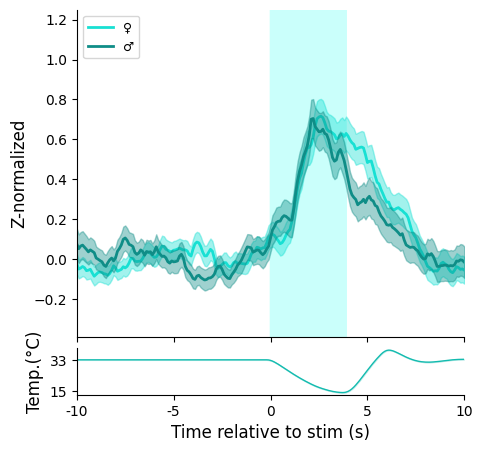

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin vers le fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_thermic_Zscore_classic_stim.xlsx'

# Lire le fichier Excel
df_combined = pd.read_excel(file_path)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000

# Compter le nombre d'animaux par sexe
if 'animal' in df_combined.columns:
    animal_count = df_combined[['animal', 'sexe']].drop_duplicates().groupby('sexe').size()
    count_m = animal_count.get('M', 0)  # Nombre d'animaux mâles
    count_f = animal_count.get('F', 0)  # Nombre d'animaux femelles
    print(f"Nombre d'animaux mâles (M) : {count_m}")
    print(f"Nombre d'animaux femelles (F) : {count_f}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'sexe' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_combined.groupby(['sexe', 'time_sec']).agg(
    Mean_Zscore_norm=('Z-score_norm', 'mean'),
    SEM_Zscore_norm=('Z-score_norm', 'sem'),
    Mean_temperature=('temperature', 'mean')
).reset_index()

# Définir les couleurs pour chaque sexe
sex_colors = {
    'F': {'mean': '#18e0d3', 'sem': '#18e0d3'},  
    'M': {'mean': '#0f8d87', 'sem': '#0f8d87'}   
}

# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()

# Tracer les courbes pour chaque sexe
for sexe, color in sex_colors.items():
    sexe_data = grouped[grouped['sexe'] == sexe]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        sexe_data['time_sec'], sexe_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{'♀' if sexe == 'F' else '♂'}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        sexe_data['time_sec'],
        sexe_data['Mean_Zscore_norm'] - sexe_data['SEM_Zscore_norm'],
        sexe_data['Mean_Zscore_norm'] + sexe_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'

# Tracer la période TS en arrière-plan, en dehors de l'ombre SEM
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] - grouped['SEM_Zscore_norm'], 
    y_min -1 ,  # Limite inférieure réelle du graphique
    where=(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9),
    color=color_ts, zorder=0
)

# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9),
    color=color_ts, zorder=0
)

# Deuxième subplot : Variation de la Température
sns.lineplot(
    data=grouped, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (°C)')

# Définir les ticks spécifiques sur l'axe y pour la température
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Définir la plage de temps pour le calcul des limites
time_range = (-10, 10)

# Filtrer les données sur la plage de temps définie
df_filtered_time = grouped[(grouped['time_sec'] >= time_range[0]) & (grouped['time_sec'] <= time_range[1])]

# Calculer les limites min et max pour y en utilisant les colonnes appropriées
y_min_time_range = (df_filtered_time['Mean_Zscore_norm'] - df_filtered_time['SEM_Zscore_norm']).min()
y_max_time_range = (df_filtered_time['Mean_Zscore_norm'] + df_filtered_time['SEM_Zscore_norm']).max()

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend(loc="upper left")


ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.39, 1.25)
ax1.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Filtrer les données pour 'time_sec' entre 0 et 3.9
filtered_data = grouped[(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9)]

# Trouver la valeur maximale de Z-score_norm pour chaque sexe
max_values_by_sex = filtered_data.groupby('sexe')['Mean_Zscore_norm'].max()

# Afficher les valeurs maximales pour chaque sexe
for sexe, max_value in max_values_by_sex.items():
    print(f"La valeur maximale de Znorm pour le sexe {sexe} (0-3.9s) est : {max_value}")


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout



# Afficher le graphique
plt.show()


## 9.2. AUC

##### 9.2.1.AUC (animals) --- ATTENTION STAT PAS FAITE


Sexe: M
TB : 0.0910 ± 0.0311, 5 
    Shapiro: 0.8764, p-value: 0.2933
        La distribution est normale (p >= 0.05)
TS : 3.8291 ± 0.8654, 5 
    Shapiro: 0.9340, p-value: 0.6242
        La distribution est normale (p >= 0.05)
PTS : 1.9892 ± 1.5503, 5 
    Shapiro: 0.8263, p-value: 0.1305
        La distribution est normale (p >= 0.05)

Sexe: F
TB : 0.2433 ± 0.0358, 7 
    Shapiro: 0.9094, p-value: 0.3918
        La distribution est normale (p >= 0.05)
TS : 4.0903 ± 0.7411, 7 
    Shapiro: 0.9059, p-value: 0.3681
        La distribution est normale (p >= 0.05)
PTS : 2.1215 ± 0.8922, 7 
    Shapiro: 0.9813, p-value: 0.9656
        La distribution est normale (p >= 0.05)


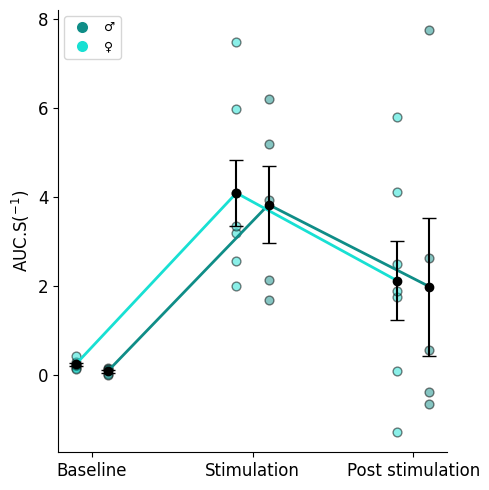

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'M' et 'F'
colors = {'M': '#0f8d87', 'F': '#18e0d3'}
border_colors = {'M': 'black', 'F': 'black'}

# Fonction pour calculer les moyennes, SEM et tailles d'échantillon
def calculate_stats(df, variable_name):
    stats = {}
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        stats[sex] = {}
        
        for period in periods:
            period_data = sex_data[sex_data['Period'] == period][variable_name]
            
            mean_value = period_data.mean()
            sem_value = period_data.sem()
            sample_size = len(period_data)
            
            stats[sex][period] = {'mean': mean_value, 'sem': sem_value, 'n': sample_size}
    
    return stats

# Fonction pour tester la normalité de Shapiro
def test_shapiro(df, variable_name):
    shapiro_results = {}
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        shapiro_results[sex] = {}
        
        for period in periods:
            period_data = sex_data[sex_data['Period'] == period][variable_name]
            stat, p_value = shapiro(period_data)
            shapiro_results[sex][period] = {'stat': stat, 'p_value': p_value}
    
    return shapiro_results

# Calcul des statistiques pour 'AUC_Znorm_persec'
variable_name = 'AUC_Znorm_persec'
stats = calculate_stats(df_auc_cool, variable_name)
shapiro_results = test_shapiro(df_auc_cool, variable_name)

# Affichage des résultats
for sex in stats.keys():
    print(f"\nSexe: {sex}")
    for period in periods:
        mean = stats[sex][period]['mean']
        sem = stats[sex][period]['sem']
        n = stats[sex][period]['n']
        shapiro_stat = shapiro_results[sex][period]['stat']
        shapiro_p_value = shapiro_results[sex][period]['p_value']
        
        print(f"{period} : {mean:.4f} ± {sem:.4f}, {n} ")
        print(f"    Shapiro: {shapiro_stat:.4f}, p-value: {shapiro_p_value:.4f}")
        
        if shapiro_p_value < 0.05:
            print(f"        La distribution n'est pas normale (p < 0.05)")
        else:
            print(f"        La distribution est normale (p >= 0.05)")

# Fonction pour tracer les graphiques
def plot_variable_sex(df, variable_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par sexe
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        
        means[sex] = {period: sex_data[sex_data['Period'] == period][variable_name].mean() for period in periods}
        sems[sex] = {period: sex_data[sex_data['Period'] == period][variable_name].sem() for period in periods}

        # Tracer les données de chaque sexe avec décalage sur l'axe x
        for period in periods:
            x_offset = 0.1 if sex == 'M' else -0.1  # Décalage pour éviter le chevauchement
            x_values = [positions[period] + x_offset] * len(sex_data[sex_data['Period'] == period])
            y_values = sex_data[sex_data['Period'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                         linewidth=1, alpha=0.5, marker='o', s=40, zorder=1)
            
            mean_value = means[sex][period]
            sem_value = sems[sex][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    
    return means, sems


# Exemple d'appel pour afficher les graphiques pour la condition 'Cool' et la variable 'AUC_Znorm_persec'
plt.figure(figsize=(5, 5))
means_sex, sems_sex = plot_variable_sex(df_auc_cool, 'AUC_Znorm_persec', colors, border_colors)


# Fonction pour afficher les connexions entre les moyennes
def plot_connections(means, sex, variable_name, color):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + (0.1 if sex == 'M' else -0.1), positions[periods[i + 1]] + (0.1 if sex == 'M' else -0.1)
        y1, y2 = means[sex][periods[i]], means[sex][periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ensuite, appelez cette fonction pour chaque sexe
for sex in df_auc_cool['Sexe'].unique():
    plot_connections(means_sex, sex, 'AUC_Znorm_persec', colors[sex])
    
# Ajouter des résultats de tests statistiques, si nécessaires
y_offset = 4.5  # Décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre les barres de significativité

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')

# Ajouter la légende en haut à gauche avec les symboles des sexes
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['M'], markersize=9, label='♂'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['F'], markersize=9, label='♀')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

plt.show()


##### 9.2.2. AUC of TS period (aniamls)

Test de Mann-Whitney U :
Statistique U : 16.0
p-value : 0.8762626262626263

Test de normalité de Shapiro-Wilk :
Pour les mâles : Statistique de Shapiro : 0.9340, p-value : 0.6242
Pour les femelles : Statistique de Shapiro : 0.9059, p-value : 0.3681
Male:
  Mean: 3.8291
  SEM: 0.8654
  n: 5
Female:
  Mean: 4.0903
  SEM: 0.7411
  n: 7


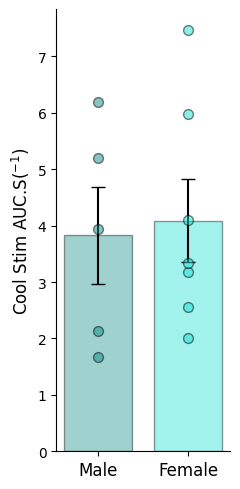

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import mannwhitneyu, shapiro

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_cool[df_auc_cool['Period'] == 'TS']

# Définir les sexes uniques
sexes = df_ts['Sexe'].unique()

# Définir les couleurs pour chaque sexe
colors = {'M': '#0f8d87', 'F': '#18e0d3'}
border_colors = {'M': 'black', 'F': 'black'}

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Résultats du test de Mann-Whitney U
print(f"Test de Mann-Whitney U :\nStatistique U : {stat}\np-value : {p_value}\n")

# Test de Shapiro-Wilk pour la normalité des données
shapiro_male = shapiro(male_data)
shapiro_female = shapiro(female_data)

# Résultats du test de Shapiro-Wilk
print("Test de normalité de Shapiro-Wilk :")
print(f"Pour les mâles : Statistique de Shapiro : {shapiro_male.statistic:.4f}, p-value : {shapiro_male.pvalue:.4f}")
print(f"Pour les femelles : Statistique de Shapiro : {shapiro_female.statistic:.4f}, p-value : {shapiro_female.pvalue:.4f}")


# Initialiser le graphique
plt.figure(figsize=(2.5, 5))

# Tracer les barres pour chaque sexe
bar_width = 0.75
positions = range(len(sexes))
for i, sex in enumerate(sexes):
    sex_data = df_ts[df_ts['Sexe'] == sex]
    mean_auc = sex_data['AUC_Znorm_persec'].mean()
    sem_auc = sex_data['AUC_Znorm_persec'].sem()
    
    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        width=bar_width,
        capsize=5,
        label='♂' if sex == 'M' else '♀',
        alpha=0.4,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(sex_data)
    y_values = sex_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        alpha=0.5,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, ['Male', 'Female'])
plt.ylabel(r'Cool Stim AUC.S($^{-1}$)')

# Calculer les statistiques pour chaque sexe
results = {}
for sex in sexes:
    sex_data = df_ts[df_ts['Sexe'] == sex]['AUC_Znorm_persec']
    results[sex] = {
        'Mean': sex_data.mean(),
        'SEM': sex_data.sem(),
        'n': len(sex_data)
    }

# Afficher les résultats
for sex, stats in results.items():
    label = 'Male' if sex == 'M' else 'Female'
    print(f"{label}:\n  Mean: {stats['Mean']:.4f}\n  SEM: {stats['SEM']:.4f}\n  n: {stats['n']}")

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Appliquer les réglages de style
plt.tight_layout()

# Afficher le graphique
plt.show()


#### 9.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE

Test de normalité de Shapiro-Wilk par sexe et période :

Sexe: M
Période: TB, Statistique de Shapiro: 0.9745, p-value: 0.0034
Moyenne: 0.0946, SEM: 0.0340, Taille de l'échantillon: 168
Période: TS, Statistique de Shapiro: 0.9859, p-value: 0.0873
Moyenne: 4.1955, SEM: 0.6545, Taille de l'échantillon: 168
Période: PTS, Statistique de Shapiro: 0.9623, p-value: 0.0002
Moyenne: 1.3789, SEM: 0.5876, Taille de l'échantillon: 168

Sexe: F
Période: TB, Statistique de Shapiro: 0.9375, p-value: 0.0000
Moyenne: 0.2253, SEM: 0.0370, Taille de l'échantillon: 232
Période: TS, Statistique de Shapiro: 0.9886, p-value: 0.0622
Moyenne: 4.2597, SEM: 0.5489, Taille de l'échantillon: 232
Période: PTS, Statistique de Shapiro: 0.9864, p-value: 0.0260
Moyenne: 2.1682, SEM: 0.5641, Taille de l'échantillon: 232


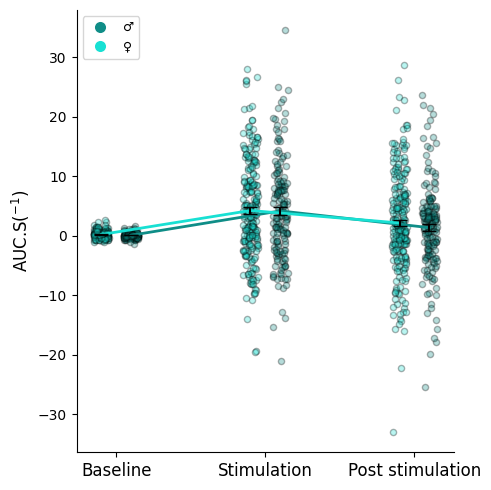

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_cool['Condition'] = 'Cool'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'M' et 'F'
colors = {'M': '#0f8d87', 'F': '#18e0d3'}
border_colors = {'M': 'black', 'F': 'black'}

# Fonction pour tracer les variables en fonction du sexe avec un "jitter"
def plot_variable_sex(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    sample_sizes = {}
    shapiro_results = {}
    
    # Calcul des moyennes, SEM, tailles d'échantillon et test de Shapiro par sexe
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        
        means[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].sem() for period in periods}
        sample_sizes[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].count() for period in periods}
        
        # Test de Shapiro-Wilk pour la normalité des données
        shapiro_results[sex] = {period: shapiro(sex_data[sex_data['Period_type'] == period][variable_name]) for period in periods}

        # Tracer les données de chaque sexe avec un décalage sur l'axe x
        for period in periods:
            # Ajouter un jitter aléatoire pour éviter le chevauchement des points
            x_offset = 0.1 if sex == 'M' else -0.1  # Décalage pour éviter le chevauchement
            jitter = np.random.uniform(-0.05, 0.05, size=len(sex_data[sex_data['Period_type'] == period]))  # Jitter
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(sex_data[sex_data['Period_type'] == period]))]
            y_values = sex_data[sex_data['Period_type'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                         linewidth=1, alpha=0.3, marker='o', s=20, zorder=1)
            
            mean_value = means[sex][period]
            sem_value = sems[sex][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='-', color='black', capsize=5, zorder=2)
    
    return means, sems, sample_sizes, shapiro_results

# Appliquer la fonction pour chaque variable (ici, 'AUC_Znorm_persec')
plt.figure(figsize=(5, 5))

# Tracer les données pour la condition Cool, dissociée par sexe
means_cool, sems_cool, sample_sizes_cool, shapiro_results_cool = plot_variable_sex(df_auc_cool, 'AUC_Znorm_persec', 'Cool', colors, border_colors)

# Affichage des résultats du test de Shapiro
print("Test de normalité de Shapiro-Wilk par sexe et période :")
for sex in ['M', 'F']:
    print(f"\nSexe: {sex}")
    for period in periods:
        stat, p_value = shapiro_results_cool[sex][period]
        print(f"Période: {period}, Statistique de Shapiro: {stat:.4f}, p-value: {p_value:.4f}")
        print(f"Moyenne: {means_cool[sex][period]:.4f}, SEM: {sems_cool[sex][period]:.4f}, Taille de l'échantillon: {sample_sizes_cool[sex][period]}")

# Ajouter des connexions entre les périodes, avec un ajustement pour chaque sexe
def plot_connections(means, color, positions, periods, x_offsets):
    for i in range(len(periods) - 1):
        # Connexion entre les périodes, mais en fonction de la position réelle des moyennes
        x1 = positions[periods[i]] + x_offsets[periods[i]]
        x2 = positions[periods[i + 1]] + x_offsets[periods[i + 1]]
        y1 = means[periods[i]]
        y2 = means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque sexe
x_offsets = {
    'M': {'TB': 0.1, 'TS': 0.1, 'PTS': 0.1},
    'F': {'TB': -0.1, 'TS': -0.1, 'PTS': -0.1}
}

# Ajouter des connexions pour chaque sexe avec les bons décalages
for sex in ['M', 'F']:
    plot_connections(means_cool[sex], colors[sex], positions, periods, x_offsets[sex])

# Ajouter la légende en haut à gauche avec les symboles des sexes
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['M'], markersize=9, label='♂'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['F'], markersize=9, label='♀')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

plt.tight_layout()
plt.show()


##### 9.2.4. AUC of TS period (trials)

Statistique U : 19403.0
p-value : 0.9409771867645349
Mean (Male): 4.195477328524204
SEM (Male): 0.6544985603943672
Mean (Female): 4.259660662463534
SEM (Female): 0.5489295770173145
Taille de l'échantillon (Male): 168
Taille de l'échantillon (Female): 232
Test de Shapiro pour les données masculines : Statistique = 0.985859664722848, p-value = 0.08727900317875999
Test de Shapiro pour les données féminines : Statistique = 0.9885739971021562, p-value = 0.06216230226936307


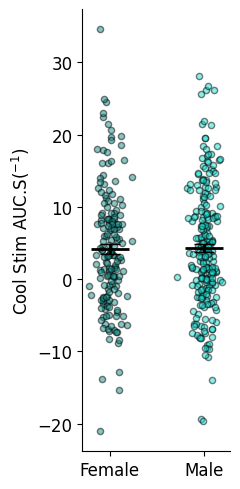

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu, shapiro

# Charger les données à partir du fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts = df_auc_cool[df_auc_cool['Period_type'] == 'TS']

# Définir les couleurs pour chaque sexe
colors = {'M': '#0f8d87', 'F': '#18e0d3'}
border_colors = {'M': 'black', 'F': 'black'}

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Afficher les résultats du test
print(f"Statistique U : {stat}")
print(f"p-value : {p_value}")

# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
male_mean = male_data.mean()
female_mean = female_data.mean()
male_sem = male_data.sem()
female_sem = female_data.sem()

# Affichage des moyennes et des SEM
print(f"Mean (Male): {male_mean}")
print(f"SEM (Male): {male_sem}")
print(f"Mean (Female): {female_mean}")
print(f"SEM (Female): {female_sem}")

# Taille des échantillons
male_n = len(male_data)
female_n = len(female_data)
print(f"Taille de l'échantillon (Male): {male_n}")
print(f"Taille de l'échantillon (Female): {female_n}")

# Test de normalité de Shapiro-Wilk
male_shapiro_stat, male_shapiro_p = shapiro(male_data)
female_shapiro_stat, female_shapiro_p = shapiro(female_data)

print(f"Test de Shapiro pour les données masculines : Statistique = {male_shapiro_stat}, p-value = {male_shapiro_p}")
print(f"Test de Shapiro pour les données féminines : Statistique = {female_shapiro_stat}, p-value = {female_shapiro_p}")

# Initialiser le graphique
plt.figure(figsize=(2.5, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
male_x = np.random.normal(0, jitter_strength, len(male_data))  # Jitter horizontal
plt.scatter(
    male_x, 
    male_data, 
    color=colors['M'], 
    edgecolor=border_colors['M'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

# Points féminins
female_x = np.random.normal(1, jitter_strength, len(female_data))  # Jitter horizontal
plt.scatter(
    female_x, 
    female_data, 
    color=colors['F'], 
    edgecolor=border_colors['F'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(male_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(female_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  

# Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, male_mean, yerr=male_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, female_mean, yerr=female_sem, color='black', ecolor='black', elinewidth=2, capsize=7)

# Réglages des axes et de la légende
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylabel(r'Cool Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Affichage du graphique
plt.tight_layout()
plt.show()


## 9.3. Response rate

##### 9.3.1 Response rate animals

Female condition: Mean = 57.11 ± SEM = 3.95
Male condition: Mean = 49.67 ± SEM = 5.81

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.7097, p-value = 0.0121
Female: Statistique = 0.6890, p-value = 0.0028
Test de Mann-Whitney : Statistique = 6.0000, p-value = 0.0730
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.

Taille des échantillons :
Male : 5
Female : 7


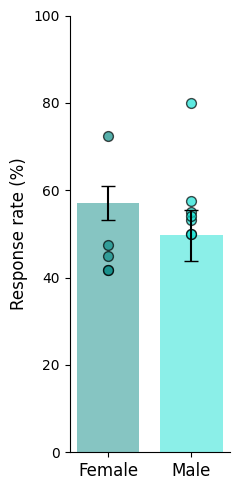

In [20]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Lecture du fichier Excel
df = pd.read_excel(file_path)

# # Vérifier les premières lignes pour s'assurer que les données sont correctes
# print(df.head())

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df[df['sexe'] == 'M']
df_female = df[df['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calculer la moyenne du taux de réponse par animal pour chaque sexe
mean_response_per_animal = combined_data.groupby(['animal', 'sexe'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = mean_response_per_animal.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
mean_response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


# Séparer les taux de réponse
response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

# Effectuer le test de Mann-Whitney
stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")

# Conclusion sur la comparaison statistique
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")


# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par sexe avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['sexe']))

# Barres pour chaque sexe

# Définir les couleurs pour chaque sexe
colors = ['#0f8d87', '#18e0d3']  # Male (bleu) et Female (orange)
for i, sexe in enumerate(mean_response_data['sexe']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim', color=colors[i], alpha = 0.5, capsize=5)

# Ajouter des points individuels pour chaque sexe
for sexe, color in zip(['Male', 'Female'], colors):
    individual_data = mean_response_per_animal[mean_response_per_animal['sexe'] == sexe]
    plt.scatter(
        [x[0] if sexe == 'Male' else x[1]] * len(individual_data),
        individual_data['response_rate'],
        color=color,
        alpha=0.7,
        edgecolor='black',
        s=50  # Taille des points
    )

# Vérification des tailles d'échantillons
sample_size_male = len(mean_response_male)  # Taille de l'échantillon pour Male
sample_size_female = len(mean_response_female)    # Taille de l'échantillon pour Female

print("\nTaille des échantillons :")
print(f"Male : {sample_size_male}")
print(f"Female : {sample_size_female}")

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['sexe'])
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


##### 9.3.2 Response rate trials

Female condition: Mean = 58.19 ± SEM = 3.25
Male condition: Mean = 51.19 ± SEM = 3.87

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.6362, p-value = 0.0000
Female: Statistique = 0.6266, p-value = 0.0000
Test de Mann-Whitney : Statistique = 18124.0000, p-value = 0.1654
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.

Taille des échantillons :
Male : 168
Female : 232


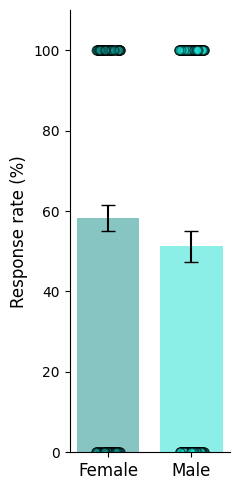

In [24]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Lecture du fichier Excel
df = pd.read_excel(file_path)

# # Vérifier les premières lignes pour s'assurer que les données sont correctes
# print(df.head())

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df[df['sexe'] == 'M']
df_female = df[df['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = combined_data.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
mean_response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


# Séparer les taux de réponse
response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

# Effectuer le test de Mann-Whitney
stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")

# Conclusion sur la comparaison statistique
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")


# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par sexe avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['sexe']))

# Barres pour chaque sexe

# Définir les couleurs pour chaque sexe
colors = ['#0f8d87', '#18e0d3']  # Male (bleu) et Female (orange)
for i, sexe in enumerate(mean_response_data['sexe']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim', color=colors[i], alpha = 0.5, capsize=5)

# Ajouter des points individuels pour chaque sexe avec jitter
for sexe, color in zip(['Male', 'Female'], colors):
    individual_data = combined_data[combined_data['sexe'] == sexe]
    
    # Générer du jitter
    jitter = np.random.uniform(-0.15, 0.15, size=len(individual_data))  # Décalage aléatoire pour éviter la superposition
    
    # Position X ajustée avec jitter
    x_position = x[0] if sexe == 'Male' else x[1]
    x_values = x_position + jitter  # Ajouter le jitter à la position
    
    # Scatter plot avec jitter
    plt.scatter(
        x_values,
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40  # Taille des points
    )

# Vérification des tailles d'échantillons
sample_size_male = len(mean_response_male)  # Taille de l'échantillon pour Male
sample_size_female = len(mean_response_female)    # Taille de l'échantillon pour Female

print("\nTaille des échantillons :")
print(f"Male : {sample_size_male}")
print(f"Female : {sample_size_female}")

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['sexe'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


#

#

# 10. Age effect

### 10.1. PSTC

Nombre de P6 : 3
Nombre de P7 : 4
Nombre de P8 : 5
La valeur maximale de Znorm pour le sexe P6 (0-3.9s) est : 0.8989057981112579
La valeur maximale de Znorm pour le sexe P7 (0-3.9s) est : 0.8680270328615799
La valeur maximale de Znorm pour le sexe P8 (0-3.9s) est : 0.5389407055021728


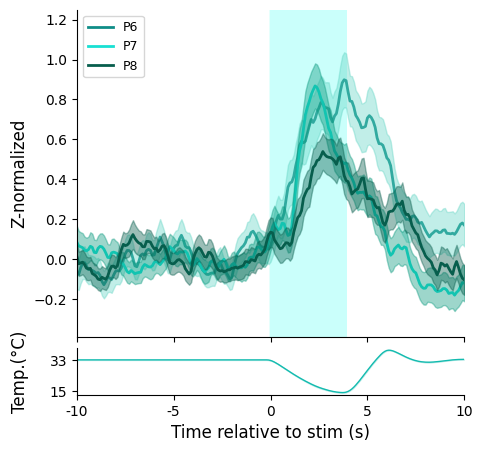

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin vers le fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Df_thermic_Zscore_classic_stim.xlsx'

# Lire le fichier Excel
df_combined = pd.read_excel(file_path)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000

# Compter le nombre d'animaux par age
if 'animal' in df_combined.columns:
    animal_count = df_combined[['animal', 'age']].drop_duplicates().groupby('age').size()
    count_p6 = animal_count.get('P6', 0)  # Nombre d'animaux mâles
    count_p7 = animal_count.get('P7', 0)  # Nombre d'animaux femelles
    count_p8 = animal_count.get('P8', 0)  # Nombre d'animaux femelles
    print(f"Nombre de P6 : {count_p6}")
    print(f"Nombre de P7 : {count_p7}")
    print(f"Nombre de P8 : {count_p8}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'age' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_combined.groupby(['age', 'time_sec']).agg(
    Mean_Zscore_norm=('Z-score_norm', 'mean'),
    SEM_Zscore_norm=('Z-score_norm', 'sem'),
    Mean_temperature=('temperature', 'mean')
).reset_index()

age_colors = {
    'P6': {'mean': '#0f8d87', 'sem': '#66d6c6'},  # Bleu-vert clair
    'P7': {'mean': '#18e0d3', 'sem': '#0a9a7f'},  # Vert plus sombre
    'P8': {'mean': '#075e4d', 'sem': '#075e4d'}   # Teinte plus sombre et intense
}


# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()


# Tracer les courbes pour chaque age
for age, color in age_colors.items():
    age_data = grouped[grouped['age'] == age]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        age_data['time_sec'], age_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{age}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        age_data['time_sec'],
        age_data['Mean_Zscore_norm'] - age_data['SEM_Zscore_norm'],
        age_data['Mean_Zscore_norm'] + age_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'

# Tracer la période TS en arrière-plan, en dehors de l'ombre SEM
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] - grouped['SEM_Zscore_norm'], 
    y_min -1 ,  # Limite inférieure réelle du graphique
    where=(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9),
    color=color_ts, zorder=0
)

# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9),
    color=color_ts, zorder=0
)

# Deuxième subplot : Variation de la Température
sns.lineplot(
    data=grouped, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temperature (°C)')

# Définir les ticks spécifiques sur l'axe y pour la température
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Définir la plage de temps pour le calcul des limites
time_range = (-10, 10)

# Filtrer les données sur la plage de temps définie
df_filtered_time = grouped[(grouped['time_sec'] >= time_range[0]) & (grouped['time_sec'] <= time_range[1])]

# Calculer les limites min et max pour y en utilisant les colonnes appropriées
y_min_time_range = (df_filtered_time['Mean_Zscore_norm'] - df_filtered_time['SEM_Zscore_norm']).min()
y_max_time_range = (df_filtered_time['Mean_Zscore_norm'] + df_filtered_time['SEM_Zscore_norm']).max()

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend(loc="upper left")

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad=15)
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.39, 1.25)
ax1.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


# Filtrer les données pour 'time_sec' entre 0 et 3.9
filtered_data = grouped[(grouped['time_sec'] >= 0) & (grouped['time_sec'] <= 3.9)]

# Trouver la valeur maximale de Z-score_norm pour chaque sexe
max_values_by_age = filtered_data.groupby('age')['Mean_Zscore_norm'].max()

# Afficher les valeurs maximales pour chaque sexe
for age, max_value in max_values_by_age.items():
    print(f"La valeur maximale de Znorm pour le sexe {age} (0-3.9s) est : {max_value}")


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout


# Afficher le graphique
plt.show()


## 10.2. AUC age

#### 10.2.1. AUC (animals)

P7 - TB: Mean = 0.22, SEM = 0.07, N = 4
Shapiro-Wilk test for P7 - TB: Stat = 0.688, p-value = 0.008
P7 - TS: Mean = 4.71, SEM = 0.86, N = 4
Shapiro-Wilk test for P7 - TS: Stat = 0.896, p-value = 0.412
P7 - PTS: Mean = 0.89, SEM = 0.83, N = 4
Shapiro-Wilk test for P7 - PTS: Stat = 0.959, p-value = 0.771
P8 - TB: Mean = 0.16, SEM = 0.05, N = 5
Shapiro-Wilk test for P8 - TB: Stat = 0.884, p-value = 0.329
P8 - TS: Mean = 2.83, SEM = 0.43, N = 5
Shapiro-Wilk test for P8 - TS: Stat = 0.919, p-value = 0.523
P8 - PTS: Mean = 1.67, SEM = 0.83, N = 5
Shapiro-Wilk test for P8 - PTS: Stat = 0.949, p-value = 0.729
P6 - TB: Mean = 0.16, SEM = 0.08, N = 3
Shapiro-Wilk test for P6 - TB: Stat = 0.992, p-value = 0.829
P6 - TS: Mean = 4.93, SEM = 1.55, N = 3
Shapiro-Wilk test for P6 - TS: Stat = 0.993, p-value = 0.836
P6 - PTS: Mean = 4.30, SEM = 2.53, N = 3
Shapiro-Wilk test for P6 - PTS: Stat = 0.914, p-value = 0.430


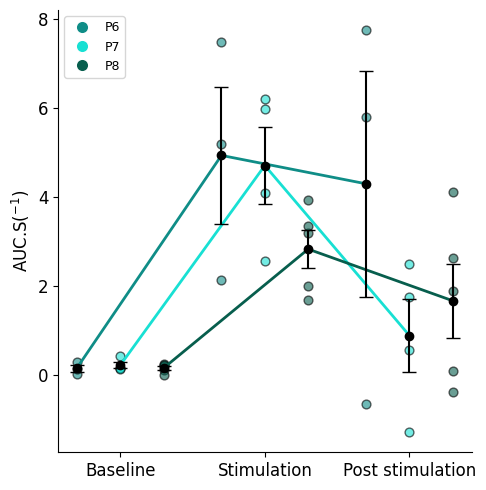

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'P6', 'P7' et 'P8'
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour tracer les variables en fonction de l'Age
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    n_samples = {}
    
    # Calcul des moyennes, SEM et taille de l'échantillon par Age et période
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period'] == period][variable_name].sem() for period in periods}
        n_samples[age] = {period: age_data[age_data['Period'] == period].shape[0] for period in periods}

        # Tracer les données de chaque Age avec décalage sur l'axe x
        for period in periods:
            x_offset = 0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0)  # Décalage spécifique pour chaque âge
            x_values = [positions[period] + x_offset] * len(age_data[age_data['Period'] == period])
            y_values = age_data[age_data['Period'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=40, zorder=1)
            
            mean_value = means[age][period]
            sem_value = sems[age][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)

            # Affichage des moyennes, SEM et taille d'échantillon
            print(f"{age} - {period}: Mean = {mean_value:.2f}, SEM = {sem_value:.2f}, N = {n_samples[age][period]}")
            
            # Test de Shapiro-Wilk pour la normalité des données
            stat, p_value = shapiro(y_values)
            print(f"Shapiro-Wilk test for {age} - {period}: Stat = {stat:.3f}, p-value = {p_value:.3f}")
    
    return means, sems, n_samples

# Exemple d'appel pour afficher les graphiques pour la condition 'Cool' et la variable 'AUC_Znorm_persec'
plt.figure(figsize=(5, 5))
means_age, sems_age, n_samples_age = plot_variable_age(df_auc_cool, 'AUC_Znorm_persec', 'Cool', colors, border_colors)

# Fonction pour afficher les connexions entre les moyennes
def plot_connections(means, age, variable_name, color):
    for i in range(len(periods) - 1):
        # Appliquer un décalage en fonction de l'âge pour chaque connexion
        x1 = positions[periods[i]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        x2 = positions[periods[i + 1]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        y1, y2 = means[age][periods[i]], means[age][periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ensuite, appelez cette fonction pour chaque Age
for age in df_auc_cool['Age'].unique():
    plot_connections(means_age, age, 'AUC_Znorm_persec', colors[age])

# Ajouter des résultats de tests statistiques, si nécessaires
y_offset = 4.5  # Décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre les barres de significativité

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')

# Ajouter la légende en haut à gauche avec les symboles des Ages
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()


#### 10.2.2. AUC TS (animals)

Statistique H : 3.4961538461538524
p-value : 0.17410844564456265
          P6        P7        P8
P6  1.000000  1.000000  0.446932
P7  1.000000  1.000000  0.282115
P8  0.446932  0.282115  1.000000
Shapiro-Wilk Test pour P6: Stat = 0.9926, p-value = 0.8360
Les données pour P6 suivent une distribution normale.
Shapiro-Wilk Test pour P7: Stat = 0.8962, p-value = 0.4123
Les données pour P7 suivent une distribution normale.
Shapiro-Wilk Test pour P8: Stat = 0.9189, p-value = 0.5230
Les données pour P8 suivent une distribution normale.
Age: P6, Mean: 4.933427382701947, SEM: 1.5460505284445913
Age: P7, Mean: 4.707016476417417, SEM: 0.8569712620077489
Age: P8, Mean: 2.8298370923794787, SEM: 0.42645545041656446


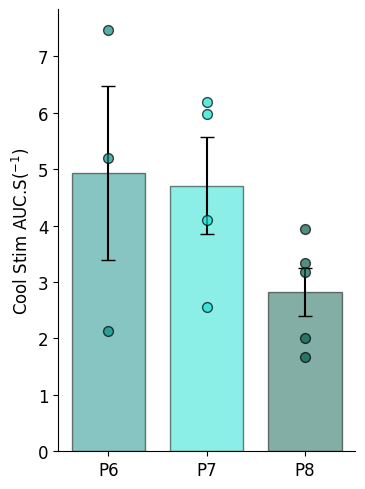

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_cool[df_auc_cool['Period'] == 'TS']

# Définir les âges uniques
ages = sorted(df_ts['Age'].unique())

# Définir les couleurs pour chaque âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts[df_ts['Age'] == age]['AUC_Znorm_persec'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats
print(posthoc)

# Test de normalité de Shapiro-Wilk pour chaque groupe d'âge
for age in ages:
    age_data = df_ts[df_ts['Age'] == age]['AUC_Znorm_persec']
    stat_shapiro, p_shapiro = shapiro(age_data)
    print(f"Shapiro-Wilk Test pour {age}: Stat = {stat_shapiro:.4f}, p-value = {p_shapiro:.4f}")
    if p_shapiro < 0.05:
        print(f"Les données pour {age} ne suivent pas une distribution normale.")
    else:
        print(f"Les données pour {age} suivent une distribution normale.")

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque âge
bar_width = 0.75
positions = range(len(ages))
for i, age in enumerate(ages):
    age_data = df_ts[df_ts['Age'] == age]
    mean_auc = age_data['AUC_Znorm_persec'].mean()
    sem_auc = age_data['AUC_Znorm_persec'].sem()
    
    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel(r'Cool Stim AUC.S($^{-1}$)')

# Calcul des moyennes et SEM pour chaque groupe d'âge
for age in ages:
    age_data = df_ts[df_ts['Age'] == age]
    mean_auc = age_data['AUC_Znorm_persec'].mean()
    sem_auc = age_data['AUC_Znorm_persec'].sem()
    print(f"Age: {age}, Mean: {mean_auc}, SEM: {sem_auc}")

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()


#### 10.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE

Moyennes, SEM et tailles d'échantillons par période et âge:

Age: P6
TB: mean = 0.159, sem = 0.049, n = 104
TS: mean = 5.364, sem = 0.826, n = 104
PTS: mean = 3.766, sem = 0.917, n = 104

Age: P7
TB: mean = 0.187, sem = 0.047, n = 136
TS: mean = 4.815, sem = 0.778, n = 136
PTS: mean = 0.604, sem = 0.655, n = 136

Age: P8
TB: mean = 0.164, sem = 0.040, n = 160
TS: mean = 3.002, sem = 0.605, n = 160
PTS: mean = 1.631, sem = 0.605, n = 160

Résultats du test de Shapiro-Wilk par période et âge (statistic, p-value):

Age: P6
TB: statistic = 0.971, p-value = 0.021
  -> Les données ne suivent pas une distribution normale.
TS: statistic = 0.986, p-value = 0.322
  -> Les données suivent une distribution normale.
PTS: statistic = 0.984, p-value = 0.257
  -> Les données suivent une distribution normale.

Age: P7
TB: statistic = 0.931, p-value = 0.000
  -> Les données ne suivent pas une distribution normale.
TS: statistic = 0.992, p-value = 0.631
  -> Les données suivent une distribution normale.


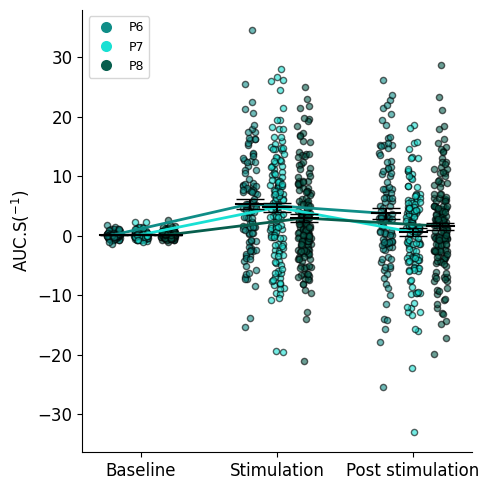

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, shapiro
from scikit_posthocs import posthoc_dunn
import os

# Chemin vers le fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_cool['Condition'] = 'Cool'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Définir les couleurs pour chaque âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour tracer les variables avec un décalage et jitter améliorés
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    ns = {}
    shapiro_results = {}  # Dictionnaire pour stocker les résultats du test de Shapiro
    
    # Calcul des moyennes, SEM et tailles d'échantillons par Age et période
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period_type'] == period][variable_name].sem() for period in periods}
        ns[age] = {period: len(age_data[age_data['Period_type'] == period]) for period in periods}

        # Test de Shapiro pour la normalité des données
        shapiro_results[age] = {}
        for period in periods:
            period_data = age_data[age_data['Period_type'] == period][variable_name]
            stat, p_value = shapiro(period_data)
            shapiro_results[age][period] = (stat, p_value)

        # Définir un décalage fixe pour chaque âge
        age_offsets = {'P6': -0.2, 'P7': 0.0, 'P8': 0.2}
        x_offset = age_offsets.get(age, 0)

        # Tracer les données de chaque Age avec un décalage sur l'axe x
        for period in periods:
            # Ajouter un jitter limité pour éviter le chevauchement
            jitter = np.random.uniform(-0.05, 0.05, size=len(age_data[age_data['Period_type'] == period]))
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(age_data[age_data['Period_type'] == period]))]
            y_values = age_data[age_data['Period_type'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=20, zorder=1)
            
            # Tracer la moyenne et SEM pour chaque âge et période
            mean_value = means[age][period]
            sem_value = sems[age][period]

            # Tracer la moyenne avec une barre horizontale (petite ligne centrale)
            plt.plot(
                [positions[period] + x_offset - 0.1, positions[period] + x_offset + 0.1],
                [mean_value, mean_value],
                color='black', linewidth=1.5, zorder=3
            )

            # Tracer les barres d'erreur verticales (SEM)
            plt.errorbar(
                positions[period] + x_offset, mean_value,
                yerr=sem_value, color='black', capsize=10, linewidth=1.5, zorder=3
            )

    return means, sems, ns, shapiro_results

# Appliquer la fonction pour tracer
plt.figure(figsize=(5, 5))
means_cool, sems_cool, ns_cool, shapiro_results_cool = plot_variable_age(df_auc_cool, 'AUC_Znorm_persec', 'Cool', colors, border_colors)

# Affichage des valeurs de mean, sem et n par période et par âge
print("Moyennes, SEM et tailles d'échantillons par période et âge:")
for age in ['P6', 'P7', 'P8']:
    print(f"\nAge: {age}")
    for period in periods:
        print(f"{period}: mean = {means_cool[age][period]:.3f}, sem = {sems_cool[age][period]:.3f}, n = {ns_cool[age][period]}")


# Affichage des résultats du test de Shapiro
print("\nRésultats du test de Shapiro-Wilk par période et âge (statistic, p-value):")
for age in ['P6', 'P7', 'P8']:
    print(f"\nAge: {age}")
    for period in periods:
        stat, p_value = shapiro_results_cool[age][period]
        print(f"{period}: statistic = {stat:.3f}, p-value = {p_value:.3f}")
        if p_value < 0.05:
            print("  -> Les données ne suivent pas une distribution normale.")
        else:
            print("  -> Les données suivent une distribution normale.")


# Fonction pour tracer les connexions entre les moyennes
def plot_connections(means, color, positions, periods, x_offsets, zorder):
    """
    Trace des connexions entre les moyennes des périodes pour un âge donné.
    """
    for i in range(len(periods) - 1):
        # Obtenir les périodes actuelles
        period1 = periods[i]
        period2 = periods[i + 1]

        # Calcul des positions x et y pour les connexions
        x1 = positions[period1] + x_offsets.get(period1, 0)
        x2 = positions[period2] + x_offsets.get(period2, 0)
        y1 = means.get(period1, np.nan)
        y2 = means.get(period2, np.nan)

        # Vérifier que les moyennes ne sont pas manquantes
        if not np.isnan(y1) and not np.isnan(y2):
            plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque âge et chaque période
x_offsets = {
    'P6': {'TB': -0.2, 'TS': -0.2, 'PTS': -0.2},
    'P7': {'TB': 0.0, 'TS': 0.0, 'PTS': 0.0},
    'P8': {'TB': 0.2, 'TS': 0.2, 'PTS': 0.2}
}

# Ajouter des connexions pour chaque âge
for age in ['P6', 'P7', 'P8']:
    age_offsets = x_offsets[age]
    plot_connections(means_cool[age], colors[age], positions, periods, age_offsets, zorder=2)


# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajouter une légende
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

plt.show()


##### 10.2.4. AUC of TS period (trials)

Shapiro-Wilk P6: Stat=0.9855712107515268, p-value=0.3220331179764154
Shapiro-Wilk P7: Stat=0.9919472619601591, p-value=0.6314300742420671
Shapiro-Wilk P8: Stat=0.9762846287674456, p-value=0.007447901836538511
kruskal Stat H : 6.88838853657694
p-value : 0.0319304790802596
          P6        P7        P8
P6  1.000000  1.000000  0.057498
P7  1.000000  1.000000  0.115894
P8  0.057498  0.115894  1.000000
Mean P6: 5.364289234522184 ± 0.8261041899388372
Mean P7: 4.8151059016922755 ± 0.7782455430916108
Mean P8: 3.0021311366446835 ± 0.6051157174606346


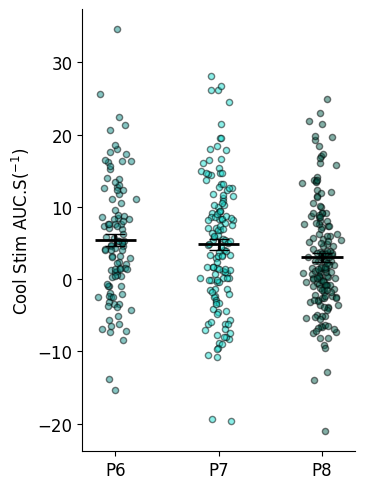

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn


# Charger les données à partir du fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts_trials = df_auc_cool[df_auc_cool['Period_type'] == 'TS']

# Définir les couleurs pour chaque âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Extraire les données pour chaque sexe
P6_data = df_ts_trials[df_ts_trials['Age'] == 'P6']['AUC_Znorm_persec']
P7_data = df_ts_trials[df_ts_trials['Age'] == 'P7']['AUC_Znorm_persec']
P8_data = df_ts_trials[df_ts_trials['Age'] == 'P8']['AUC_Znorm_persec']


# Définir les âges uniques
ages = sorted(df_ts_trials['Age'].unique())

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts_trials[df_ts_trials['Age'] == age]['AUC_Znorm_persec'] for age in ages]


# Test de Shapiro-Wilk pour chaque groupe d'âge
shapiro_p6 = shapiro(P6_data)
shapiro_p7 = shapiro(P7_data)
shapiro_p8 = shapiro(P8_data)

# Afficher les résultats des tests de normalité
print(f"Shapiro-Wilk P6: Stat={shapiro_p6.statistic}, p-value={shapiro_p6.pvalue}")
print(f"Shapiro-Wilk P7: Stat={shapiro_p7.statistic}, p-value={shapiro_p7.pvalue}")
print(f"Shapiro-Wilk P8: Stat={shapiro_p8.statistic}, p-value={shapiro_p8.pvalue}")

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"kruskal Stat H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts_trials, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats
print(posthoc)


# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
P6_mean = P6_data.mean()
P7_mean = P7_data.mean()
P8_mean = P8_data.mean()

P6_sem = P6_data.sem()
P7_sem = P7_data.sem()
P8_sem = P8_data.sem()

# Affichage des moyennes et des SEM
print(f"Mean P6: {P6_mean} ± {P6_sem}")
print(f"Mean P7: {P7_mean} ± {P7_sem}")
print(f"Mean P8: {P8_mean} ± {P8_sem}")


# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
p6_x = np.random.normal(0, jitter_strength, len(P6_data))  # Jitter horizontal
plt.scatter(
    p6_x, 
    P6_data, 
    color=colors['P6'], 
    edgecolor=border_colors['P6'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p7_x = np.random.normal(1, jitter_strength, len(P7_data))  # Jitter horizontal
plt.scatter(
    p7_x, 
    P7_data, 
    color=colors['P7'], 
    edgecolor=border_colors['P7'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p8_x = np.random.normal(2, jitter_strength, len(P8_data))  # Jitter horizontal
plt.scatter(
    p8_x, 
    P8_data, 
    color=colors['P8'], 
    edgecolor=border_colors['P8'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)


# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(P6_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(P7_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  
plt.hlines(P8_mean, 1.8, 2.2, colors='black', linestyles='solid', linewidth=2)  


# # Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, P6_mean, yerr=P6_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, P7_mean, yerr=P7_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(2, P8_mean, yerr=P8_sem, color='black', ecolor='black', elinewidth=2, capsize=7)


# Réglages des axes et de la légende
plt.xticks([0, 1, 2], ['P6', 'P7', 'P8'])
plt.ylabel(r'Cool Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()




plt.show()


Shapiro-Wilk P6: Stat=0.9855712107515268, p-value=0.3220331179764154
Shapiro-Wilk P7: Stat=0.9919472619601591, p-value=0.6314300742420671
Shapiro-Wilk P8: Stat=0.9762846287674456, p-value=0.007447901836538511
Mean P6: 5.364289234522184 ± 0.8261041899388372, n=104
Mean P7: 4.8151059016922755 ± 0.7782455430916108, n=136
Mean P8: 3.0021311366446835 ± 0.6051157174606346, n=160
Kruskal-Wallis Stat H: 6.88838853657694, p-value: 0.0319304790802596
          P6        P7        P8
P6  1.000000  1.000000  0.057498
P7  1.000000  1.000000  0.115894
P8  0.057498  0.115894  1.000000


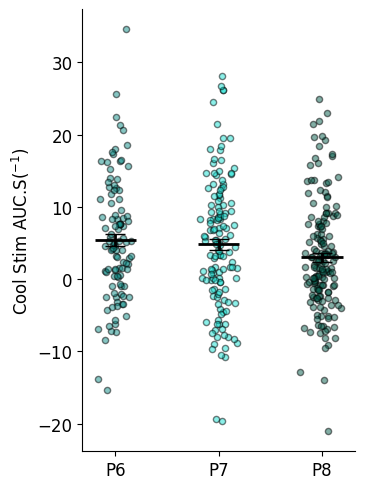

In [17]:
from scipy.stats import shapiro
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

# Charger les données à partir du fichier Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_Thq.xlsx'
df_auc_cool = pd.read_excel(file_path_auc_cool)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts_trials = df_auc_cool[df_auc_cool['Period_type'] == 'TS']

# Définir les couleurs pour chaque âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Extraire les données pour chaque sexe
P6_data = df_ts_trials[df_ts_trials['Age'] == 'P6']['AUC_Znorm_persec']
P7_data = df_ts_trials[df_ts_trials['Age'] == 'P7']['AUC_Znorm_persec']
P8_data = df_ts_trials[df_ts_trials['Age'] == 'P8']['AUC_Znorm_persec']

# Taille des échantillons
n_p6 = len(P6_data)
n_p7 = len(P7_data)
n_p8 = len(P8_data)

# Test de Shapiro-Wilk pour chaque groupe d'âge
shapiro_p6 = shapiro(P6_data)
shapiro_p7 = shapiro(P7_data)
shapiro_p8 = shapiro(P8_data)

# Afficher les résultats des tests de normalité
print(f"Shapiro-Wilk P6: Stat={shapiro_p6.statistic}, p-value={shapiro_p6.pvalue}")
print(f"Shapiro-Wilk P7: Stat={shapiro_p7.statistic}, p-value={shapiro_p7.pvalue}")
print(f"Shapiro-Wilk P8: Stat={shapiro_p8.statistic}, p-value={shapiro_p8.pvalue}")

# Calcul de la moyenne, SEM et n pour chaque groupe
P6_mean = P6_data.mean()
P7_mean = P7_data.mean()
P8_mean = P8_data.mean()

P6_sem = P6_data.sem()
P7_sem = P7_data.sem()
P8_sem = P8_data.sem()

# Affichage des moyennes, SEM et tailles d'échantillons
print(f"Mean P6: {P6_mean} ± {P6_sem}, n={n_p6}")
print(f"Mean P7: {P7_mean} ± {P7_sem}, n={n_p7}")
print(f"Mean P8: {P8_mean} ± {P8_sem}, n={n_p8}")

# Test de Kruskal-Wallis
stat, p_value = kruskal(P6_data, P7_data, P8_data)

# Résultats du test de Kruskal-Wallis
print(f"Kruskal-Wallis Stat H: {stat}, p-value: {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts_trials, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points pour chaque groupe
p6_x = np.random.normal(0, jitter_strength, len(P6_data))  # Jitter horizontal
plt.scatter(
    p6_x, 
    P6_data, 
    color=colors['P6'], 
    edgecolor=border_colors['P6'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p7_x = np.random.normal(1, jitter_strength, len(P7_data))  # Jitter horizontal
plt.scatter(
    p7_x, 
    P7_data, 
    color=colors['P7'], 
    edgecolor=border_colors['P7'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p8_x = np.random.normal(2, jitter_strength, len(P8_data))  # Jitter horizontal
plt.scatter(
    p8_x, 
    P8_data, 
    color=colors['P8'], 
    edgecolor=border_colors['P8'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

# Tracer la ligne de la moyenne pour chaque groupe
plt.hlines(P6_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(P7_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  
plt.hlines(P8_mean, 1.8, 2.2, colors='black', linestyles='solid', linewidth=2)  

# Ajouter des barres d'erreur pour la SEM
plt.errorbar(0, P6_mean, yerr=P6_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, P7_mean, yerr=P7_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(2, P8_mean, yerr=P8_sem, color='black', ecolor='black', elinewidth=2, capsize=7)

# Réglages des axes et de la légende
plt.xticks([0, 1, 2], ['P6', 'P7', 'P8'])
plt.ylabel(r'Cool Stim AUC.S($^{-1}$)')

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()


### 10.3. Response rate

##### 10.3.1. Response rate (animals)

Statistique H : 2.7225645539906043
p-value : 0.2563318776587374
          P6        P7        P8
P6  1.000000  0.803038  1.000000
P7  0.803038  1.000000  0.323672
P8  1.000000  0.323672  1.000000
Age: P6, Mean: 56.39%, SEM: 11.93%, n: 3
Age: P7, Mean: 58.75%, SEM: 4.84%, n: 4
Age: P8, Mean: 48.79%, SEM: 2.39%, n: 5


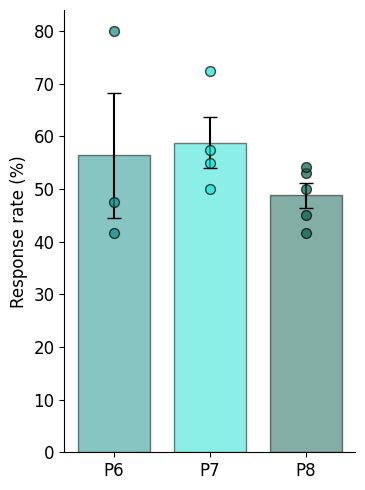

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Séparer les données par groupe d'âge
df_p6 = df[df['age'] == 'P6']
df_p7 = df[df['age'] == 'P7']
df_p8 = df[df['age'] == 'P8']

# Calcul du taux de réponse moyen par animal et par âge
response_data_p6 = df_p6.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p7 = df_p7.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p8 = df_p8.groupby(['animal', 'age'])['response_rate'].mean().reset_index()

# Combiner les données des trois groupes d'âge
combined_data = pd.concat([response_data_p6, response_data_p7, response_data_p8])

# Convertir le taux de réponse en pourcentage
combined_data['response_rate'] = combined_data['response_rate'] * 100

# Définir les âges uniques
ages = sorted(combined_data['age'].unique())

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [combined_data[combined_data['age'] == age]['response_rate'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(combined_data, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge
bar_width = 0.75
positions = range(len(ages))

for i, age in enumerate(ages):
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')


# Calcul de la moyenne, SEM et n pour chaque groupe d'âge
for age in ages:
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()
    n = len(age_data)
    
    print(f"Age: {age}, Mean: {mean_response:.2f}%, SEM: {sem_response:.2f}%, n: {n}")


# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()



# Afficher le graphique
plt.show()


Statistique H : 2.7225645539906043
p-value : 0.2563318776587374
          P6        P7        P8
P6  1.000000  0.803038  1.000000
P7  0.803038  1.000000  0.323672
P8  1.000000  0.323672  1.000000
Shapiro-Wilk Test pour P6: Statistique = 0.861, p-value = 0.271
Les données pour P6 suivent une distribution normale.
Shapiro-Wilk Test pour P7: Statistique = 0.897, p-value = 0.414
Les données pour P7 suivent une distribution normale.
Shapiro-Wilk Test pour P8: Statistique = 0.923, p-value = 0.548
Les données pour P8 suivent une distribution normale.
Age: P6, Mean: 56.39%, SEM: 11.93%, n: 3
Age: P7, Mean: 58.75%, SEM: 4.84%, n: 4
Age: P8, Mean: 48.79%, SEM: 2.39%, n: 5


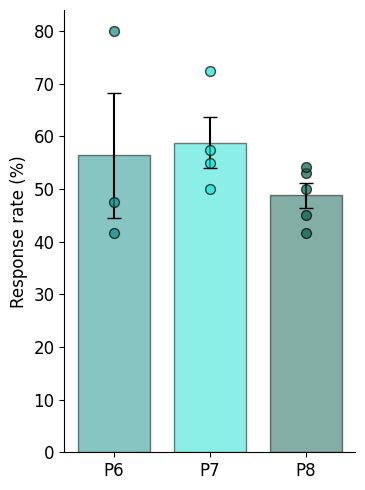

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Séparer les données par groupe d'âge
df_p6 = df[df['age'] == 'P6']
df_p7 = df[df['age'] == 'P7']
df_p8 = df[df['age'] == 'P8']

# Calcul du taux de réponse moyen par animal et par âge
response_data_p6 = df_p6.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p7 = df_p7.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p8 = df_p8.groupby(['animal', 'age'])['response_rate'].mean().reset_index()

# Combiner les données des trois groupes d'âge
combined_data = pd.concat([response_data_p6, response_data_p7, response_data_p8])

# Convertir le taux de réponse en pourcentage
combined_data['response_rate'] = combined_data['response_rate'] * 100

# Définir les âges uniques
ages = sorted(combined_data['age'].unique())

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [combined_data[combined_data['age'] == age]['response_rate'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(combined_data, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Test de Shapiro-Wilk pour chaque groupe d'âge
for age in ages:
    age_data = combined_data[combined_data['age'] == age]['response_rate']
    
    # Test de normalité de Shapiro-Wilk
    stat_shapiro, p_value_shapiro = shapiro(age_data)
    print(f"Shapiro-Wilk Test pour {age}: Statistique = {stat_shapiro:.3f}, p-value = {p_value_shapiro:.3f}")
    
    # Vérification de la normalité
    if p_value_shapiro > 0.05:
        print(f"Les données pour {age} suivent une distribution normale.")
    else:
        print(f"Les données pour {age} ne suivent pas une distribution normale.")

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge
bar_width = 0.75
positions = range(len(ages))

for i, age in enumerate(ages):
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Calcul de la moyenne, SEM et n pour chaque groupe d'âge
for age in ages:
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()
    n = len(age_data)
    
    print(f"Age: {age}, Mean: {mean_response:.2f}%, SEM: {sem_response:.2f}%, n: {n}")

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()


##### 10.3.2 Response rate (Trials)

Statistique H : 4.6094848418747985
p-value : 0.09978449974160858
          P6        P7        P8
P6  1.000000  1.000000  0.342782
P7  1.000000  1.000000  0.140402
P8  0.342782  0.140402  1.000000
Age: P6, Mean: 58.65%, SEM: 4.85%, n: 104
Shapiro-Wilk Test pour P6: Statistique = 0.625, p-value = 0.000
Les données pour P6 ne suivent pas une distribution normale.
Age: P7, Mean: 60.29%, SEM: 4.21%, n: 136
Shapiro-Wilk Test pour P7: Statistique = 0.621, p-value = 0.000
Les données pour P7 ne suivent pas une distribution normale.
Age: P8, Mean: 48.75%, SEM: 3.96%, n: 160
Shapiro-Wilk Test pour P8: Statistique = 0.636, p-value = 0.000
Les données pour P8 ne suivent pas une distribution normale.


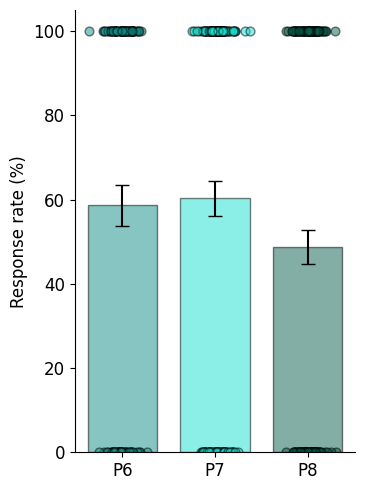

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal, shapiro
from scikit_posthocs import posthoc_dunn

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Thq_2/Thresholding_thq/Thq_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Convertir le taux de réponse en pourcentage
df['response_rate'] = df['response_rate'] * 100

# Filtrer les données par groupe d'âge
ages = sorted(df['age'].unique())  # Identifier les groupes d'âge uniques

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

# Test de Kruskal-Wallis
data_by_age = [df[df['age'] == age]['response_rate'] for age in ages]
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Calcul de la moyenne, SEM et n pour chaque groupe d'âge
for age in ages:
    age_data = df[df['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()
    n = len(age_data)
    
    print(f"Age: {age}, Mean: {mean_response:.2f}%, SEM: {sem_response:.2f}%, n: {n}")
    
    # Test de normalité de Shapiro-Wilk
    stat_shapiro, p_value_shapiro = shapiro(age_data['response_rate'])
    print(f"Shapiro-Wilk Test pour {age}: Statistique = {stat_shapiro:.3f}, p-value = {p_value_shapiro:.3f}")
    if p_value_shapiro > 0.05:
        print(f"Les données pour {age} suivent une distribution normale.")
    else:
        print(f"Les données pour {age} ne suivent pas une distribution normale.")

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge avec les points individuels
bar_width = 0.75
positions = range(len(ages))
jitter_strength = 0.1  # Contrôle l'intensité du jitter

for i, age in enumerate(ages):
    age_data = df[df['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal avec jitter
    jitter = np.random.normal(0, jitter_strength, size=len(age_data))
    x_values = np.array([positions[i]] * len(age_data)) + jitter
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.5,
        marker='o',
        s=40,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 12,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Afficher le graphique
plt.show()
